In [1]:
import pandas as pd
import numpy as np 
import matplotlib as plt
import sklearn as sl
import os


In [2]:
data = pd.read_csv('CTF_clean.csv')

data['complex']=data['H_real'].values+ 1j*data['H_imag'].values
print(f"Rows loaded: {len(data)}")
print(f"Complex dtype: {data['complex'].dtype}")

Rows loaded: 3626733
Complex dtype: complex128


C:\Users\USER\AppData\Local\Temp\ipykernel_22660\3723202117.py:3: RuntimeWarning: invalid value encountered in multiply
  data['complex']=data['H_real'].values+ 1j*data['H_imag'].values


In [3]:
print(f"NaN in H_real  : {data['H_real'].isna().sum()}")
print(f"NaN in H_imag  : {data['H_imag'].isna().sum()}")
print(f"NaN in complex : {data['complex'].isna().sum()}")

# Show which rows have NaN
nan_rows = data[data['H_real'].isna() | data['H_imag'].isna()]
print(f"\nTotal rows with NaN: {len(nan_rows)}")
print(nan_rows[['x', 'y', 'z', 'Angle of turn table', 'Frequency(Hz)', 'H_real', 'H_imag']].head(10))

NaN in H_real  : 0
NaN in H_imag  : 0
NaN in complex : 1

Total rows with NaN: 0
Empty DataFrame
Columns: [x, y, z, Angle of turn table, Frequency(Hz), H_real, H_imag]
Index: []


In [4]:
# Find the row where complex is NaN
nan_complex_idx = data[data['complex'].isna()].index
print(f"Index of NaN complex row: {nan_complex_idx}")
print(data.loc[nan_complex_idx, ['x', 'y', 'z', 'Angle of turn table', 
                                  'Frequency(Hz)', 'H_real', 'H_imag']])

Index of NaN complex row: RangeIndex(start=3396261, stop=3396262, step=1)
         x    y     z  Angle of turn table  Frequency(Hz)  H_real  H_imag
3396261  1  3.0  1.52                    0     8000000000    -inf    -inf


In [5]:
new_magnitude_db = -33.01   # <-- change this to your desired dB value
new_phase_deg    = -165.65   # <-- change this to your desired phase value

# Apply fix
idx = 3396261
data.loc[idx, 'Magnitude(db)']  = new_magnitude_db
data.loc[idx, 'Phase(degrees)'] = new_phase_deg
data.loc[idx, 'H_real']         = 10**(new_magnitude_db/20) * np.cos(np.deg2rad(new_phase_deg))
data.loc[idx, 'H_imag']         = 10**(new_magnitude_db/20) * np.sin(np.deg2rad(new_phase_deg))
data.loc[idx, 'complex']        = data.loc[idx, 'H_real'] + 1j * data.loc[idx, 'H_imag']

# Verify
print(data.loc[idx, ['Frequency(Hz)', 'Magnitude(db)', 'Phase(degrees)', 
                      'H_real', 'H_imag', 'complex']])


Frequency(Hz)     8.000000e+09+0.000000e+00j
Magnitude(db)    -3.301000e+01+0.000000e+00j
Phase(degrees)   -1.656500e+02+0.000000e+00j
H_real           -2.166377e-02+0.000000e+00j
H_imag           -5.542164e-03+0.000000e+00j
complex          -2.166377e-02-5.542164e-03j
Name: 3396261, dtype: complex128


In [7]:
# Convert all columns except complex back to float64
float_cols = ['Frequency(Hz)', 'Magnitude(db)', 'Phase(degrees)', 
              'x', 'y', 'z', 'Angle of turn table', 'H_real', 'H_imag']

for col in float_cols:
    data[col] = data[col].astype(float)

# Verify dtypes
print(data.dtypes)

# Verify the fixed row looks correct
print(f"\nFixed row:")
print(data.loc[3396261, ['Frequency(Hz)', 'Magnitude(db)', 'Phase(degrees)', 
                          'H_real', 'H_imag', 'complex']])

# Verify no inf or NaN remaining
print(f"\nNaN in complex : {data['complex'].isna().sum()}")
print(f"Inf in H_real  : {np.isinf(data['H_real']).sum()}")
print(f"Inf in H_imag  : {np.isinf(data['H_imag'].astype(float)).sum()}")

Frequency(Hz)             float64
Magnitude(db)             float64
Phase(degrees)            float64
Angle of turn table       float64
x                         float64
y                         float64
z                         float64
H_real                    float64
H_imag                    float64
complex                complex128
dtype: object

Fixed row:
Frequency(Hz)     8.000000e+09+0.000000e+00j
Magnitude(db)    -3.301000e+01+0.000000e+00j
Phase(degrees)   -1.656500e+02+0.000000e+00j
H_real           -2.166377e-02+0.000000e+00j
H_imag           -5.542164e-03+0.000000e+00j
complex          -2.166377e-02-5.542164e-03j
Name: 3396261, dtype: complex128

NaN in complex : 0
Inf in H_real  : 0
Inf in H_imag  : 0


In [6]:
data.head()

,Frequency(Hz),Magnitude(db),Phase(degrees),Angle of turn table,x,y,z,H_real,H_imag,complex
0,8000000000,-22.42076,-70.99882,0,0,1.0,1.52,0.024639,-0.071553,0.024639-0.071553j
1,8001250000,-22.70777,-69.50725,0,0,1.0,1.52,0.025632,-0.068584,0.025632-0.068584j
2,8002500000,-22.54431,-75.13818,0,0,1.0,1.52,0.019136,-0.072112,0.019136-0.072112j
3,8003750000,-23.10117,-79.66623,0,0,1.0,1.52,0.012552,-0.068840,0.012552-0.068840j
4,8005000000,-22.74971,-87.64665,0,0,1.0,1.52,0.002992,-0.072803,0.002992-0.072803j


In [8]:
print("=== DATASET READY FOR TRAINING ===")
print(f"Total rows     : {len(data)}")
print(f"NaN values     : {data.isna().sum().sum()}")
print(f"Inf values     : {np.isinf(data[['H_real','H_imag']]).sum().sum()}")
print(f"Dtypes correct : {all(data[col].dtype == 'float64' for col in ['Frequency(Hz)','x','y','z','H_real','H_imag'])}")

=== DATASET READY FOR TRAINING ===
Total rows     : 3626733
NaN values     : 0
Inf values     : 0
Dtypes correct : True


In [9]:
#Normalizing data
#Frequency norm
data['f_norm']=(data['Frequency(Hz)']-data['Frequency(Hz)'].min()) / (data['Frequency(Hz)'].max()-data['Frequency(Hz)'].min())
# X norm
data['x_norm'] = (data['x'] - data['x'].min()) / (data['x'].max() - data['x'].min())
# y norm
data['y_norm'] = (data['y'] - data['y'].min()) / (data['y'].max() - data['y'].min())
# z norm
data['z_norm'] = (data['z'] - data['z'].min()) / (data['z'].max() - data['z'].min())

print("Normalized ranges:")
print(f"  f_norm : {data['f_norm'].min():.4f} to {data['f_norm'].max():.4f}")
print(f"  x_norm : {data['x_norm'].min():.4f} to {data['x_norm'].max():.4f}")
print(f"  y_norm : {data['y_norm'].min():.4f} to {data['y_norm'].max():.4f}")
print(f"  z_norm : {data['z_norm'].min():.4f} to {data['z_norm'].max():.4f}")

Normalized ranges:
  f_norm : 0.0000 to 1.0000
  x_norm : 0.0000 to 1.0000
  y_norm : 0.0000 to 1.0000
  z_norm : 0.0000 to 1.0000


In [10]:
#Periodic Encoding for Angle
#Why not normalize angle to [0,1]?
#Because 0° and 340° are only 20° apart physically but would be 0.0 and 1.0 numerically.
#the network would think they are maximally different. Sin/cos encoding preserves the circular geometry:

# Converting angle to radians then encoding as sin/cos
data['angle_rad'] = np.deg2rad(data['Angle of turn table'])
data['angle_sin'] = np.sin(data['angle_rad'])
data['angle_cos'] = np.cos(data['angle_rad'])

# Verify
print("\nAngle encoding check:")
print(f"  0°   → sin={np.sin(np.deg2rad(0)):.4f},  cos={np.cos(np.deg2rad(0)):.4f}")
print(f"  90°  → sin={np.sin(np.deg2rad(90)):.4f},  cos={np.cos(np.deg2rad(90)):.4f}")
print(f"  180° → sin={np.sin(np.deg2rad(180)):.4f},  cos={np.cos(np.deg2rad(180)):.4f}")
print(f"  340° → sin={np.sin(np.deg2rad(340)):.4f}, cos={np.cos(np.deg2rad(340)):.4f}")


Angle encoding check:
  0°   → sin=0.0000,  cos=1.0000
  90°  → sin=1.0000,  cos=0.0000
  180° → sin=0.0000,  cos=-1.0000
  340° → sin=-0.3420, cos=0.9397


In [11]:
# Defining final input columns
input_cols = ['f_norm', 'x_norm', 'y_norm', 'z_norm', 'angle_sin', 'angle_cos']

X = data[input_cols].values
print(f"\nInput matrix shape : {X.shape}")
print(f"Expected           : (3626733, 6)")
print(f"\nSample row 0: {X[0]}")
print(f"Sample row 1: {X[1]}")


Input matrix shape : (3626733, 6)
Expected           : (3626733, 6)

Sample row 0: [0.         0.         0.09090909 1.         0.         1.        ]
Sample row 1: [3.12500000e-04 0.00000000e+00 9.09090909e-02 1.00000000e+00
 0.00000000e+00 1.00000000e+00]


In [12]:
# Target: real and imaginary parts of complex CTF
y_real = data['H_real'].values
y_imag = data['H_imag'].values

print(f"\nTarget shapes:")
print(f"  y_real : {y_real.shape}")
print(f"  y_imag : {y_imag.shape}")

print(f"\nTarget statistics:")
print(f"  H_real — min: {y_real.min():.6f}, max: {y_real.max():.6f}, mean: {y_real.mean():.6f}")
print(f"  H_imag — min: {y_imag.min():.6f}, max: {y_imag.max():.6f}, mean: {y_imag.mean():.6f}")


Target shapes:
  y_real : (3626733,)
  y_imag : (3626733,)

Target statistics:
  H_real — min: -0.806006, max: 0.810866, mean: 0.001407
  H_imag — min: -0.743888, max: 0.801088, mean: 0.000800


In [14]:
#Fourier Feature Encoding

def fourier_feature_encoding(X, B):
    """
    X : (N, 4) normalized inputs [f, x, y, z]
    B : (4, m) random frequency matrix
    Returns : (N, 2m) encoded features
    """
    X_proj = X @ B                          
    return np.concatenate([
        np.sin(2 * np.pi * X_proj),
        np.cos(2 * np.pi * X_proj)
    ], axis=1)                              

# --- Prepare spatial inputs ---
X_spatial = data[['f_norm', 'x_norm', 'y_norm', 'z_norm']].values
print(f"Spatial input shape : {X_spatial.shape}")

# --- Set random seed ---
np.random.seed(42)

# --- Parameters ---
sigma = 10.0
m = 256

# --- Random frequency matrix ---
B = np.random.randn(4, m) * sigma
print(f"B matrix shape      : {B.shape}")

# --- Apply Fourier encoding ---
X_fourier = fourier_feature_encoding(X_spatial, B)
print(f"Fourier encoded shape: {X_fourier.shape}")

# --- Angle encoding ---
angle_enc = data[['angle_sin', 'angle_cos']].values
print(f"Angle encoded shape  : {angle_enc.shape}")

# --- Combine ---
X_final = np.concatenate([X_fourier, angle_enc], axis=1)
print(f"\nFinal input shape    : {X_final.shape}")
print(f"Expected             : (3626733, 514)")

# --- Sanity checks ---
print(f"\nAny NaN in X_final   : {np.isnan(X_final).sum()}")
print(f"Any Inf in X_final   : {np.isinf(X_final).sum()}")
print(f"Min value            : {X_final.min():.4f}")
print(f"Max value            : {X_final.max():.4f}")
print(f"\nSample row 0 (first 6 values): {X_final[0, :6]}")


Spatial input shape : (3626733, 4)
B matrix shape      : (4, 256)
Fourier encoded shape: (3626733, 512)
Angle encoded shape  : (3626733, 2)

Final input shape    : (3626733, 514)
Expected             : (3626733, 514)

Any NaN in X_final   : 0
Any Inf in X_final   : 0
Min value            : -1.0000
Max value            : 1.0000

Sample row 0 (first 6 values): [-0.0822414   0.95216154 -0.32796723  0.38007863 -0.98292124 -0.85474117]


Fourier Feature Encoding
This is the most critical encoding step. CTF oscillates rapidly with frequency — a plain MLP cannot capture this. Fourier encoding maps inputs into a high-dimensional space of sinusoids.

What Problem Are We Solving?
our CTF signal oscillates rapidly with frequency. For example between 8 GHz and 12 GHz you have 3201 points of rapidly changing magnitude and phase. A plain neural network with inputs like [0.0, 0.1, 0.2...] cannot learn these rapid oscillations because it sees smooth numbers but the output is wiggling fast.
Fourier encoding solves this by converting smooth inputs into many oscillating signals before feeding them to the network.

Visual Summary

Raw inputs          Encoding              Network input
──────────          ────────              ─────────────
f_norm   ┐
x_norm   ├──→  Fourier encoding  ──→  512 features  ┐
y_norm   │     (random matrix B)                     ├──→ 514 features
z_norm   ┘                                           │    into SIREN
                                                     │
angle°   ──→   sin/cos encoding  ──→  2 features   ──┘

Matplotlib is building the font cache; this may take a moment.


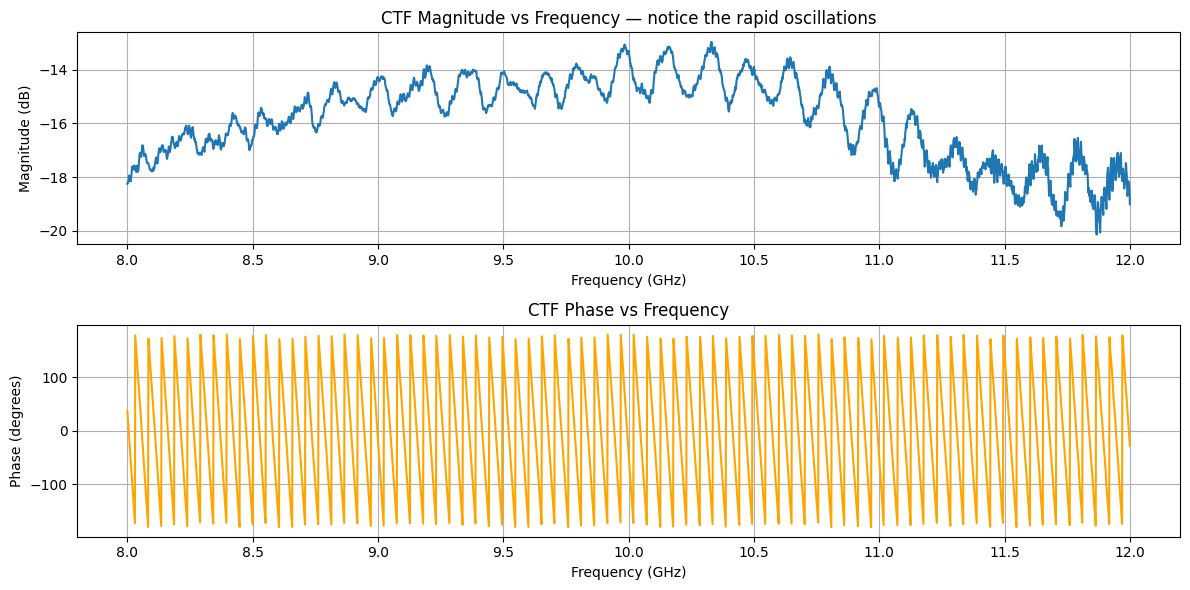

Plot saved as CTF_oscillation.png


In [13]:
import matplotlib.pyplot as plt

# Pick one position and one angle
sweep = data[(data['x']==0) & (data['y']==4.0) & 
             (data['z']==0.8) & (data['Angle of turn table']==0)]
sweep = sweep.sort_values('Frequency(Hz)')

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6))

# Magnitude in dB
ax1.plot(sweep['Frequency(Hz)']/1e9, sweep['Magnitude(db)'])
ax1.set_xlabel('Frequency (GHz)')
ax1.set_ylabel('Magnitude (dB)')
ax1.set_title('CTF Magnitude vs Frequency — notice the rapid oscillations')
ax1.grid(True)

# Phase
ax2.plot(sweep['Frequency(Hz)']/1e9, sweep['Phase(degrees)'], color='orange')
ax2.set_xlabel('Frequency (GHz)')
ax2.set_ylabel('Phase (degrees)')
ax2.set_title('CTF Phase vs Frequency')
ax2.grid(True)

plt.tight_layout()
plt.savefig('CTF_oscillation.png', dpi=150)
plt.show()
print("Plot saved as CTF_oscillation.png")

In [15]:
np.save('fourier_B_matrix.npy', B)
print(f"Saved B matrix: shape {B.shape}, sigma={sigma}, m={m}")

# Verify it saves and reloads correctly
B_check = np.load('fourier_B_matrix.npy')
print(f"Reloaded B matrix: shape {B_check.shape}")
print(f"Identical to original: {np.allclose(B, B_check)}")

Saved B matrix: shape (4, 256), sigma=10.0, m=256
Reloaded B matrix: shape (4, 256)
Identical to original: True


In [16]:
# Get all unique spatial positions (x, y, z) — excluding angle
# We split by (x,y,z) so all angles at a held-out position are in test set
positions = data[['x', 'y', 'z']].drop_duplicates().reset_index(drop=True)
print(f"Total unique (x,y,z) positions: {len(positions)}")
print(positions.sort_values(['z','x','y']).to_string(index=False))

Total unique (x,y,z) positions: 63
  x    y    z
0.0  0.5 0.80
0.0  1.0 0.80
0.0  2.0 0.80
0.0  4.0 0.80
0.0  5.0 0.80
0.0  6.0 0.80
0.0  7.0 0.80
0.0  8.0 0.80
0.0  9.0 0.80
0.0 10.0 0.80
0.0 11.0 0.80
1.0  0.0 0.80
1.0  2.0 0.80
1.0  3.0 0.80
1.0 11.0 0.80
2.0  0.0 0.80
2.0  1.0 0.80
2.0  2.0 0.80
2.0  3.0 0.80
2.0  7.0 0.80
2.0 11.0 0.80
3.0  0.0 0.80
3.0  5.0 0.80
3.0  6.0 0.80
3.0  7.0 0.80
3.0  8.0 0.80
3.0  9.0 0.80
3.0 10.0 0.80
3.0 11.0 0.80
4.0  6.0 0.80
0.0  1.0 1.52
0.0  2.0 1.52
0.0  3.0 1.52
0.0  4.0 1.52
0.0  5.0 1.52
0.0  6.0 1.52
0.0  7.0 1.52
0.0  8.0 1.52
0.0  9.0 1.52
0.0 10.0 1.52
0.0 11.0 1.52
1.0  0.0 1.52
1.0  1.0 1.52
1.0  2.0 1.52
1.0  3.0 1.52
1.0  7.0 1.52
1.0 11.0 1.52
2.0  0.0 1.52
2.0  1.0 1.52
2.0  2.0 1.52
2.0  3.0 1.52
2.0  7.0 1.52
2.0 11.0 1.52
3.0  0.0 1.52
3.0  4.0 1.52
3.0  5.0 1.52
3.0  6.0 1.52
3.0  7.0 1.52
3.0  8.0 1.52
3.0  9.0 1.52
3.0 10.0 1.52
3.0 11.0 1.52
4.0  6.0 1.52


In [17]:
from sklearn.model_selection import train_test_split

# Split unique positions: 70% train, 15% val, 15% test
train_pos, temp_pos = train_test_split(positions, test_size=0.30, random_state=42)
val_pos, test_pos   = train_test_split(temp_pos,  test_size=0.50, random_state=42)

print(f"Train positions : {len(train_pos)}")
print(f"Val positions   : {len(val_pos)}")
print(f"Test positions  : {len(test_pos)}")

Train positions : 44
Val positions   : 9
Test positions  : 10


In [18]:
# Merge to assign each row to train/val/test
train_pos['split'] = 'train'
val_pos['split']   = 'val'
test_pos['split']  = 'test'

split_labels = pd.concat([train_pos, val_pos, test_pos])

# Merge split labels back into main data
data = data.merge(split_labels, on=['x','y','z'], how='left')

# Verify
print(f"\nSplit distribution:")
print(data['split'].value_counts())
print(f"\nExpected train rows : ~{int(len(data)*0.70):,}")
print(f"Expected val rows   : ~{int(len(data)*0.15):,}")
print(f"Expected test rows  : ~{int(len(data)*0.15):,}")


Split distribution:
split
train    2531991
test      576180
val       518562
Name: count, dtype: int64

Expected train rows : ~2,538,713
Expected val rows   : ~544,009
Expected test rows  : ~544,009


In [19]:
# Input columns
input_cols = ['f_norm', 'x_norm', 'y_norm', 'z_norm', 'angle_sin', 'angle_cos']

# Get indices for each split
train_idx = data[data['split']=='train'].index
val_idx   = data[data['split']=='val'].index
test_idx  = data[data['split']=='test'].index

# Input arrays
X_train = X_final[train_idx]
X_val   = X_final[val_idx]
X_test  = X_final[test_idx]

# Target arrays
y_train = np.stack([data.loc[train_idx, 'H_real'].values,
                    data.loc[train_idx, 'H_imag'].values], axis=1)
y_val   = np.stack([data.loc[val_idx,   'H_real'].values,
                    data.loc[val_idx,   'H_imag'].values], axis=1)
y_test  = np.stack([data.loc[test_idx,  'H_real'].values,
                    data.loc[test_idx,  'H_imag'].values], axis=1)

print(f"\nX_train : {X_train.shape}")
print(f"X_val   : {X_val.shape}")
print(f"X_test  : {X_test.shape}")
print(f"y_train : {y_train.shape}")
print(f"y_val   : {y_val.shape}")
print(f"y_test  : {y_test.shape}")


X_train : (2531991, 514)
X_val   : (518562, 514)
X_test  : (576180, 514)
y_train : (2531991, 2)
y_val   : (518562, 2)
y_test  : (576180, 2)


In [20]:
# Save all arrays
np.save('X_train.npy', X_train)
np.save('X_val.npy',   X_val)
np.save('X_test.npy',  X_test)
np.save('y_train.npy', y_train)
np.save('y_val.npy',   y_val)
np.save('y_test.npy',  y_test)

# Verify
print("Saved successfully:")
print(f"  X_train : {X_train.shape} — {X_train.nbytes/1e9:.2f} GB")
print(f"  X_val   : {X_val.shape}   — {X_val.nbytes/1e9:.2f} GB")
print(f"  X_test  : {X_test.shape}  — {X_test.nbytes/1e9:.2f} GB")
print(f"  y_train : {y_train.shape} — {y_train.nbytes/1e6:.2f} MB")
print(f"  y_val   : {y_val.shape}   — {y_val.nbytes/1e6:.2f} MB")
print(f"  y_test  : {y_test.shape}  — {y_test.nbytes/1e6:.2f} MB")

Saved successfully:
  X_train : (2531991, 514) — 10.41 GB
  X_val   : (518562, 514)   — 2.13 GB
  X_test  : (576180, 514)  — 2.37 GB
  y_train : (2531991, 2) — 40.51 MB
  y_val   : (518562, 2)   — 8.30 MB
  y_test  : (576180, 2)  — 9.22 MB
